# Import libraries and packages 

In [286]:
import os
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

# Data Ingestion and load

In [287]:
def read_data(path: str) -> pd.DataFrame:
    if path.split('.')[-1] == 'csv':
        df = pd.read_csv(path)
    elif path.split('.')[-1] in ['xls', 'xlsx']:
        df = pd.read_excel(path)
    else:
        raise ValueError("Unsupported file format. Please provide a CSV or Excel file.")
    return df

In [288]:
raw_df = read_data('/Users/aadityaraj/Projects/Forecasting_Master/Demand_forecasting/fmcg_demand_forecasting/data/extended_fmcg_demand_forecasting.csv')
print(raw_df.shape)
raw_df.head()

(1000, 10)


,Date,Product_Category,Sales_Volume,Price,Promotion,Store_Location,Weekday,Supplier_Cost,Replenishment_Lead_Time,Stock_Level
0,2022-01-01,Household,1583,5.190661,0,Urban,5,9.299281,9,207
1,2022-01-02,Personal Care,1103,8.949596,0,Urban,6,13.274109,5,253
2,2022-01-03,Dairy,455,4.867987,0,Rural,0,13.302265,9,245
3,2022-01-04,Personal Care,1107,16.968596,1,Urban,1,10.056158,5,265
4,2022-01-05,Personal Care,1447,4.309673,1,Rural,2,3.562862,8,334


* **Date:** Date on which transaction occured
* **Product_Category:** Category for which product belongs ( Household,Personal Care, Dairy etc.)
* **Sales volumes:** Quantity of units sold over a specific period.
* **price:** Selling price of each product to customers.
* **Promotion:** Discounts or special offers applied to products.
* **Store locations:** Classification of stores by area type (urban, suburban, rural).
* **Supplier costs:** Cost incurred to purchase products from suppliers.
* **Replenishment lead times:** Time taken to restock products after placing an order.
* **Stock levels:** Quantity of inventory currently available in stores or warehouses.

# preprocessing 

In [289]:
raw_df.describe()

,Sales_Volume,Price,Promotion,Weekday,Supplier_Cost,Replenishment_Lead_Time,Stock_Level
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1048.781000,10.362358,0.491000,2.999000,7.552047,4.970000,266.494000
std,539.688298,5.420627,0.500169,2.001751,4.163729,2.589944,130.560078
min,101.000000,1.003580,0.000000,0.000000,0.500445,1.000000,50.000000
25%,591.750000,5.541108,0.000000,1.000000,3.887763,3.000000,152.000000
50%,1064.500000,10.404366,0.000000,3.000000,7.422058,5.000000,260.000000
75%,1489.000000,15.054035,1.000000,5.000000,11.099853,7.000000,376.000000
max,1997.000000,19.944485,1.000000,6.000000,14.993587,9.000000,499.000000


In [290]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     1000 non-null   object 
 1   Product_Category         1000 non-null   object 
 2   Sales_Volume             1000 non-null   int64  
 3   Price                    1000 non-null   float64
 4   Promotion                1000 non-null   int64  
 5   Store_Location           1000 non-null   object 
 6   Weekday                  1000 non-null   int64  
 7   Supplier_Cost            1000 non-null   float64
 8   Replenishment_Lead_Time  1000 non-null   int64  
 9   Stock_Level              1000 non-null   int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 78.2+ KB


In [291]:
# convert categorical features into numeric 

df = raw_df.copy()

encoder = LabelEncoder()
df["Product_Category_encoded"] = encoder.fit_transform(df["Product_Category"])
df["Store_Location_encoded"] = encoder.fit_transform(df["Store_Location"])

# convert date into datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')

print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Date                      1000 non-null   datetime64[ns]
 1   Product_Category          1000 non-null   object        
 2   Sales_Volume              1000 non-null   int64         
 3   Price                     1000 non-null   float64       
 4   Promotion                 1000 non-null   int64         
 5   Store_Location            1000 non-null   object        
 6   Weekday                   1000 non-null   int64         
 7   Supplier_Cost             1000 non-null   float64       
 8   Replenishment_Lead_Time   1000 non-null   int64         
 9   Stock_Level               1000 non-null   int64         
 10  Product_Category_encoded  1000 non-null   int64         
 11  Store_Location_encoded    1000 non-null   int64         
dtypes: datetime64[ns](1),

,Date,Product_Category,Sales_Volume,Price,Promotion,Store_Location,Weekday,Supplier_Cost,Replenishment_Lead_Time,Stock_Level,Product_Category_encoded,Store_Location_encoded
0,2022-01-01,Household,1583,5.190661,0,Urban,5,9.299281,9,207,2,2
1,2022-01-02,Personal Care,1103,8.949596,0,Urban,6,13.274109,5,253,3,2
2,2022-01-03,Dairy,455,4.867987,0,Rural,0,13.302265,9,245,1,0
3,2022-01-04,Personal Care,1107,16.968596,1,Urban,1,10.056158,5,265,3,2
4,2022-01-05,Personal Care,1447,4.309673,1,Rural,2,3.562862,8,334,3,0


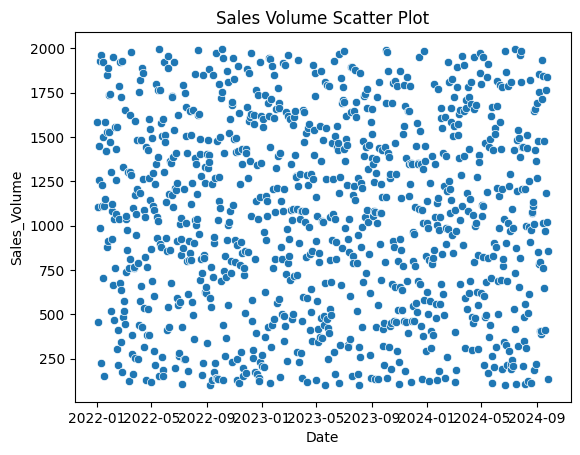

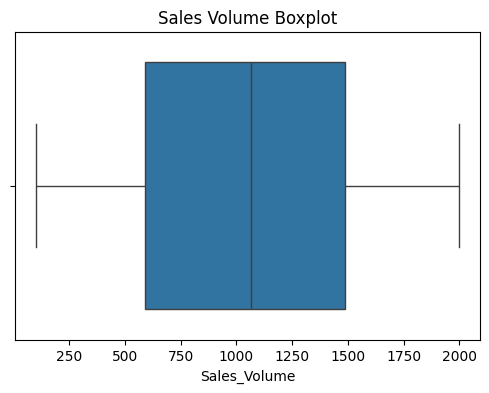

In [292]:
# outliers detection


# using scatter plot
sns.scatterplot(x=df['Date'], y=df['Sales_Volume'])
plt.title("Sales Volume Scatter Plot")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df['Sales_Volume'])
plt.title("Sales Volume Boxplot")
plt.show()


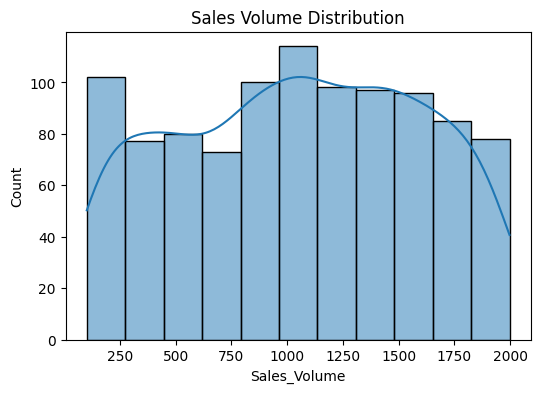

In [293]:
# check data distribution 

plt.figure(figsize=(6,4))
sns.histplot(df['Sales_Volume'], kde=True)
plt.title("Sales Volume Distribution")
plt.show()

In [294]:
Q1 = df['Sales_Volume'].quantile(0.25)
Q3 = df['Sales_Volume'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Sales_Volume'] < lower_bound) | (df['Sales_Volume'] > upper_bound)]
outliers.head()


,Date,Product_Category,Sales_Volume,Price,Promotion,Store_Location,Weekday,Supplier_Cost,Replenishment_Lead_Time,Stock_Level,Product_Category_encoded,Store_Location_encoded


* **from the above graphs and statistical method we can clearly see there are no such outliers to handle, data looks clean and uniformly distributed

In [295]:
df.groupby('Promotion')['Sales_Volume'].agg(['count', 'mean', 'median', 'std'])


,count,mean,median,std
Promotion,,,,
0,509,1036.170923,1038.0,529.098145
1,491,1061.853360,1088.0,550.686713


# check impact of promotion 

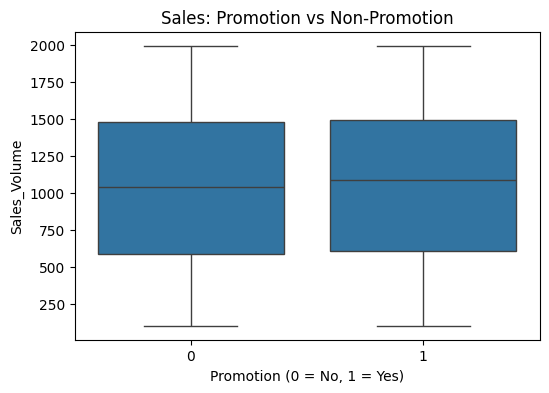

In [296]:


plt.figure(figsize=(6,4))
sns.boxplot(x='Promotion', y='Sales_Volume', data=df)
plt.title("Sales: Promotion vs Non-Promotion")
plt.xlabel("Promotion (0 = No, 1 = Yes)")
plt.show()


# Sales over time 

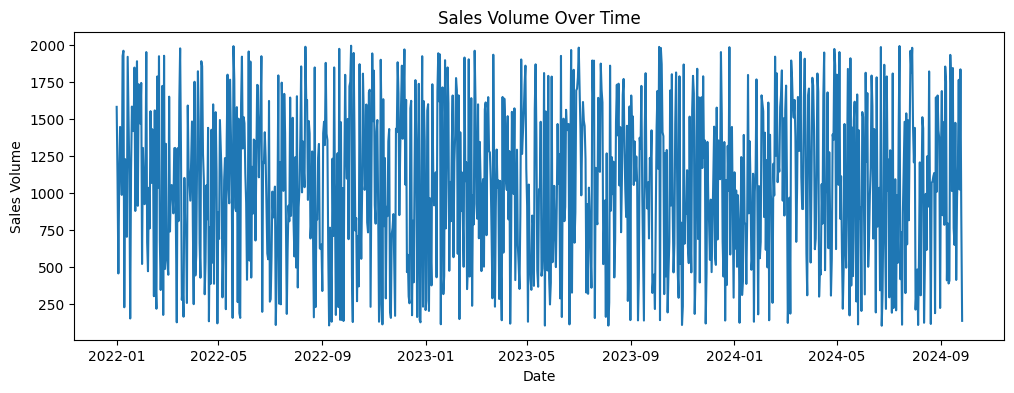

In [297]:
plt.figure(figsize=(12,4))
plt.plot(df['Date'], df['Sales_Volume'])
plt.title("Sales Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Sales Volume")
plt.show()


Text(0, 0.5, 'Total Sales Volume')

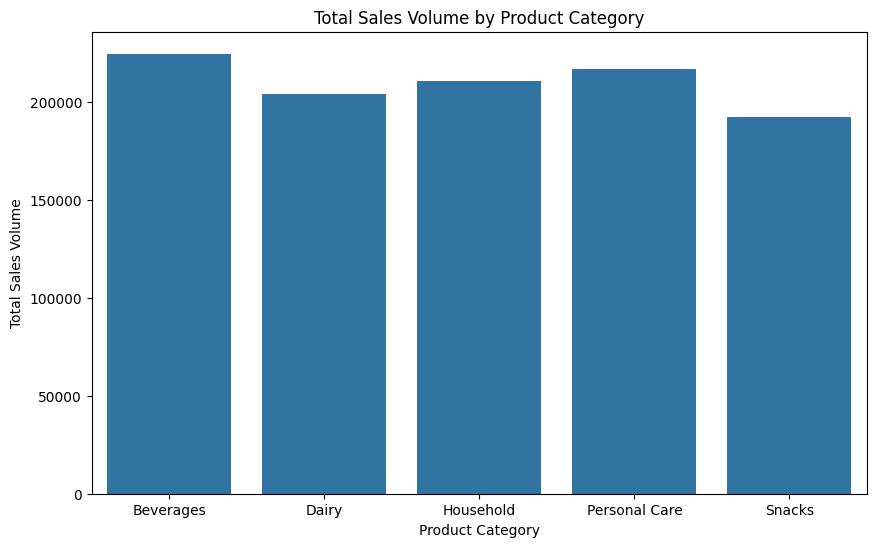

In [298]:
# Segment Analysis 


# Proceed with your analysis
segment_sales = df.groupby('Product_Category')['Sales_Volume'].sum().reset_index()


segment_sales = df.groupby('Product_Category')['Sales_Volume'].sum().reset_index()
plt.figure(figsize=(10,6))
sns.barplot(x='Product_Category', y='Sales_Volume', data=segment_sales)
plt.title("Total Sales Volume by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales Volume")

# Feature Engineering and Transformation 

In [299]:
# create lag faetures 

df = df.sort_values('Date')

# for volume 
df['sales_lag_1'] = df['Sales_Volume'].shift(1)
df['sales_lag_7'] = df['Sales_Volume'].shift(7)
df['sales_lag_14'] = df['Sales_Volume'].shift(14)

# for price
df['price_lag_1'] = df['Price'].shift(1)
df['price_lag_7'] = df['Price'].shift(7)

# for promo
df['promo_lag_1'] = df['Promotion'].shift(1)
df['promo_lag_7'] = df['Promotion'].shift(7)

# for stock level/existing stock
df['stock_lag_1'] = df['Stock_Level'].shift(1)

# rolling statistics features
df['sales_roll_mean_7'] = df['Sales_Volume'].shift(1).rolling(7).mean()
df['sales_roll_std_7'] = df['Sales_Volume'].shift(1).rolling(7).std()
df['sales_roll_mean_28'] = df['Sales_Volume'].shift(1).rolling(28).mean()

df = df.dropna()
df.head()

,Date,Product_Category,Sales_Volume,Price,Promotion,Store_Location,Weekday,Supplier_Cost,Replenishment_Lead_Time,Stock_Level,...,sales_lag_7,sales_lag_14,price_lag_1,price_lag_7,promo_lag_1,promo_lag_7,stock_lag_1,sales_roll_mean_7,sales_roll_std_7,sales_roll_mean_28
28,2022-01-29,Household,1469,15.744004,0,Suburban,5,3.556500,8,320,...,1849.0,1501.0,5.480050,19.850533,1.0,0.0,314.0,1475.142857,420.311959,1274.392857
29,2022-01-30,Household,1745,8.700893,0,Rural,6,3.825804,3,461,...,878.0,1113.0,15.744004,6.393236,0.0,0.0,320.0,1420.857143,387.215026,1270.321429
30,2022-01-31,Dairy,519,12.435252,0,Rural,0,7.302055,2,457,...,1530.0,150.0,8.700893,7.823870,0.0,1.0,461.0,1544.714286,316.913087,1293.250000
31,2022-02-01,Household,1305,13.018270,1,Urban,1,4.394151,1,237,...,1892.0,1152.0,12.435252,8.293096,0.0,1.0,457.0,1400.285714,501.407923,1295.535714
32,2022-02-02,Household,1082,8.084124,0,Urban,2,1.964183,4,468,...,913.0,1585.0,13.018270,9.850443,1.0,1.0,237.0,1316.428571,452.130459,1302.607143


# Correlation & Relationship Analysis

In [300]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()
corr_matrix


,Sales_Volume,Price,Promotion,Weekday,Supplier_Cost,Replenishment_Lead_Time,Stock_Level,Product_Category_encoded,Store_Location_encoded,sales_lag_1,sales_lag_7,sales_lag_14,price_lag_1,price_lag_7,promo_lag_1,promo_lag_7,stock_lag_1,sales_roll_mean_7,sales_roll_std_7,sales_roll_mean_28
Sales_Volume,1.000000,-0.016840,0.021930,-0.016588,0.032170,0.064580,-0.015364,-0.031444,0.051036,0.006694,-0.031892,0.024570,0.055581,0.025477,-0.022049,-0.011679,-0.044563,-0.006011,-0.020688,-0.004245
Price,-0.016840,1.000000,0.005978,-0.013005,-0.036671,0.065840,-0.016358,0.044459,0.006775,0.030518,0.033874,0.058121,-0.013978,0.036754,-0.024669,-0.034213,-0.061635,0.056919,-0.011480,0.054029
Promotion,0.021930,0.005978,1.000000,-0.000522,-0.023351,-0.005815,-0.029344,0.002594,0.012486,0.050451,0.016316,-0.025888,0.041554,-0.007731,0.049185,0.001880,-0.001629,0.035002,0.042270,0.001747
Weekday,-0.016588,-0.013005,-0.000522,1.000000,-0.001355,0.019294,-0.011250,-0.025080,0.011232,0.026402,-0.018923,-0.019701,0.011451,-0.012775,0.010792,-0.003606,0.024921,-0.001520,-0.015197,-0.000709
Supplier_Cost,0.032170,-0.036671,-0.023351,-0.001355,1.000000,0.002691,-0.031752,0.013960,0.011799,-0.009270,0.028533,-0.001003,-0.016572,-0.029448,-0.046455,0.011624,0.078923,0.016344,-0.008745,0.031178
Replenishment_Lead_Time,0.064580,0.065840,-0.005815,0.019294,0.002691,1.000000,-0.041121,0.008637,-0.010630,-0.006949,-0.021410,-0.018951,0.019913,-0.020676,-0.037670,-0.047191,-0.000409,-0.027125,0.041479,-0.046989
Stock_Level,-0.015364,-0.016358,-0.029344,-0.011250,-0.031752,-0.041121,1.000000,-0.008095,-0.002928,0.049813,-0.019004,0.009669,0.014915,0.020802,-0.028122,-0.037561,0.046376,-0.012564,0.011879,-0.011810
Product_Category_encoded,-0.031444,0.044459,0.002594,-0.025080,0.013960,0.008637,-0.008095,1.000000,0.044989,0.008164,0.012640,-0.006928,-0.027139,0.012319,-0.003222,-0.011901,0.011898,0.008263,0.043695,-0.001320
Store_Location_encoded,0.051036,0.006775,0.012486,0.011232,0.011799,-0.010630,-0.002928,0.044989,1.000000,0.034566,0.032413,0.012350,0.003980,0.000042,-0.034962,-0.004994,0.014052,0.003159,0.016227,-0.022418
sales_lag_1,0.006694,0.030518,0.050451,0.026402,-0.009270,-0.006949,0.049813,0.008164,0.034566,1.000000,0.028856,-0.052921,-0.016641,-0.035060,0.024653,-0.011747,-0.016218,0.387762,-0.030484,0.189794


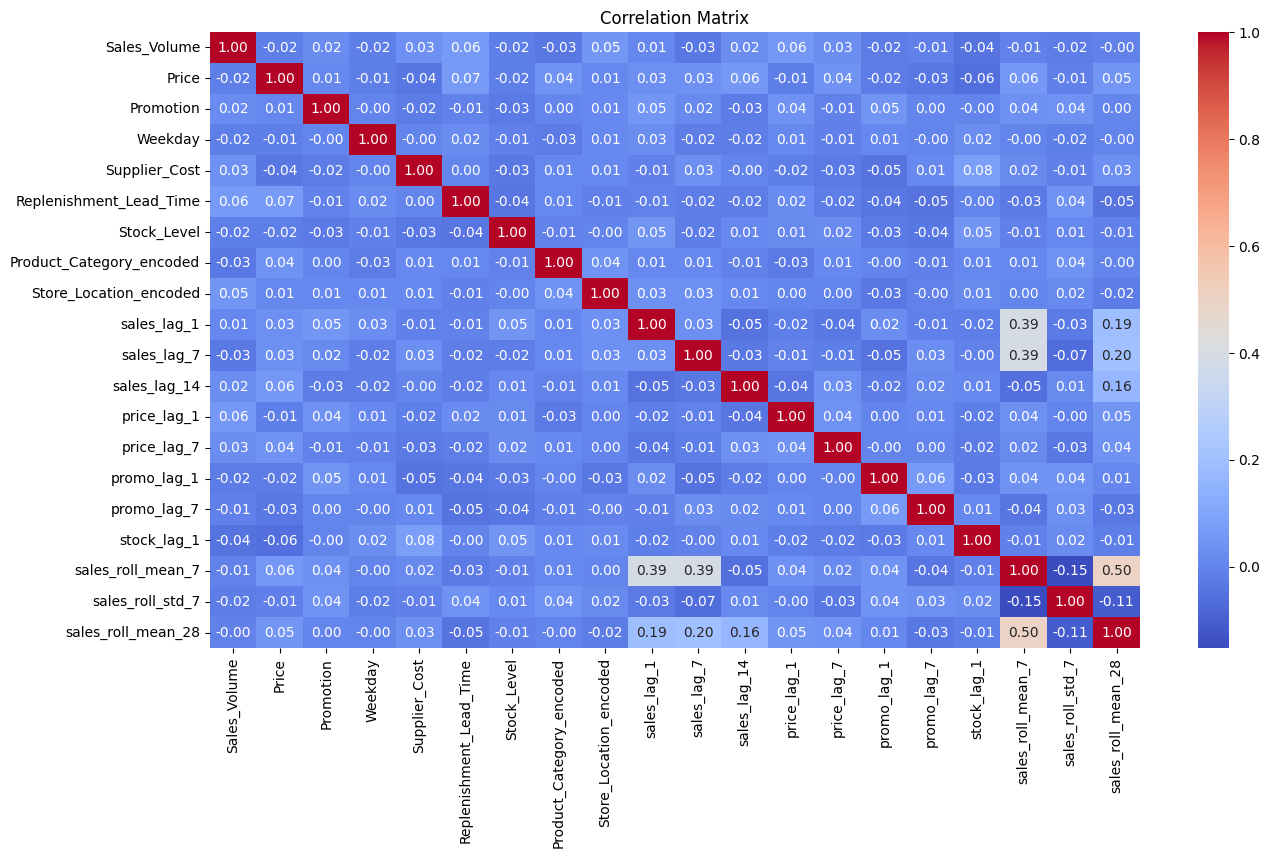

In [301]:
plt.figure(figsize=(15,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()


# Feature Selection 

1.Mutual Information (Best First Upgrade)
Why it works

* Measures any dependency, not just linear

* Detects threshold & step effects (e.g., promotions)

* When to use: ** 

* Early feature screening

* Mixed data types

* Before model training

In [302]:
from sklearn.feature_selection import mutual_info_regression

threshold = 20  # Define your threshold value here
df['low_stock_flag'] = (df['Stock_Level'] <= threshold).astype(int)

X = df.drop(columns=['Sales_Volume'])
X= X.select_dtypes(include=[np.number])
y = df['Sales_Volume']

mi = mutual_info_regression(X, y, random_state=42)
mi_scores = pd.Series(mi, index=X.columns).sort_values(ascending=False)

mi_scores


sales_lag_7                 0.028360
price_lag_1                 0.027136
Product_Category_encoded    0.024533
Price                       0.022778
promo_lag_1                 0.022342
sales_lag_14                0.020873
promo_lag_7                 0.017554
Weekday                     0.015057
stock_lag_1                 0.014469
Store_Location_encoded      0.010424
Stock_Level                 0.000000
sales_lag_1                 0.000000
Replenishment_Lead_Time     0.000000
Promotion                   0.000000
Supplier_Cost               0.000000
price_lag_7                 0.000000
sales_roll_mean_7           0.000000
sales_roll_std_7            0.000000
sales_roll_mean_28          0.000000
low_stock_flag              0.000000
dtype: float64

2.Tree-Based Feature Importance (Random Forest / XGBoost)
* Why it works

Captures:

* Non-linearity

* Interactions

* Threshold effects

* Industry standard for demand forecasting

In [303]:
from sklearn.ensemble import RandomForestRegressor


model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X, y)

feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance


price_lag_1                 0.087543
sales_roll_std_7            0.076264
stock_lag_1                 0.075572
Supplier_Cost               0.074283
sales_lag_7                 0.074099
Price                       0.070746
sales_roll_mean_28          0.070432
sales_roll_mean_7           0.069424
sales_lag_1                 0.069205
sales_lag_14                0.068523
price_lag_7                 0.067318
Stock_Level                 0.064882
Replenishment_Lead_Time     0.039754
Weekday                     0.027865
Product_Category_encoded    0.025298
Store_Location_encoded      0.015448
Promotion                   0.008437
promo_lag_1                 0.007962
promo_lag_7                 0.006943
low_stock_flag              0.000000
dtype: float64

# ML Models 

In [309]:
# Linear Regression 
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


imp_features = feature_importance.head(16).index.tolist()

x = df.drop(columns=['Sales_Volume'])[imp_features]
x = x.select_dtypes(include=[np.number])
y = df['Sales_Volume']

train_size = int(0.8 * len(df))
X_train, X_test = x[:train_size], x[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

lr_model = LinearRegression()
scaler = StandardScaler()

# Fit on train set and transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model.fit(X_train_scaled, y_train)
y_pred = lr_model.predict(X_test_scaled)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)


In [310]:
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R-squared: {r2}")

MAE: 476.5035093398777
MSE: 309936.5100236992
RMSE: 556.7194176815635
R-squared: 0.003941594845050633
